# Support Vector Machine with a Radial Basis Function kernel

In [1]:
import sys; sys.path.insert(0, "..")

from utils.dependencies import *
from utils import (
    load_and_filter, impute, split_and_balance, FEATURES,
    get_class_meta,
    run_grid_search,
    print_classification_report, compute_f1_scores, run_stratified_cv, print_error_patterns,
    plot_f1_bar, plot_confusion_matrices, plot_posterior_violins,
)

## Model-Specific Data Processing

In [2]:
df = load_and_filter()
df = impute(df)

LOG_COLS = ["pl_bmasse", "pl_orbper", "pl_orbsmax", "sy_dist"]
for col in LOG_COLS:
    df[col] = np.log1p(df[col].clip(lower=0))

for col in FEATURES:
    lo, hi = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower=lo, upper=hi)

X_train_bal, y_train_bal, X_test_scaled, y_test, class_weight_dict, scaler = split_and_balance(
    df,
    scaler=RobustScaler(),
    smote_variant="borderline",
)

class_names, classes, colors = get_class_meta()

Loaded: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_eqt          

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[Tier 4] RF Iterative Imputer on planetary features (train): 343 → 0 nulls
[Tier 5a] st_met: filled 343 via grouped median by spectral type (train)
[Tier 5b] st_age: filled 988 via RF regression + median fallback (train)
[Tier 6] KNN imputer (train): 97 → 0 nulls

Train distribution (BEFORE balancing):
P_HABITABLE
0.0    4399
1.0      23
2.0      33
Name: count, dtype: int64

Train distribution (AFTER balancing):
P_HABITABLE
0.0    299
1.0    200
2.0    198
Name: count, dtype: int64
Balanced train shape: (697, 17)
Class weights: {np.int64(0): np.float64(0.7770345596432553), np.int64(1): np.float64(1.1616666666666666), np.int64(2): np.float64(1.1734006734006734)}

Outputs ready for modeling:
  X_train_bal       → (697, 17) (balanced, scaled)
  y_train_bal       → 697 samples
  X_test_scaled     → (1114, 17) (held-out, scaled)
  y_test            → 1114 samples (original distribution)
  class_weight_dict → for class_weight param in classifiers


## Training

In [3]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1, 10],
}

grid_rbf = run_grid_search(
    SVC(kernel="rbf", class_weight=class_weight_dict, probability=True, random_state=42),
    param_grid,
    X_train_bal,
    y_train_bal,
)
svm_rbf = grid_rbf.best_estimator_

y_pred_rbf = svm_rbf.predict(X_test_scaled)
y_prob_rbf = svm_rbf.predict_proba(X_test_scaled)
y_dec_rbf  = svm_rbf.decision_function(X_test_scaled)

print("RBF SVM training complete.")
print(f"Best C:     {grid_rbf.best_params_['C']}")
print(f"Best gamma: {grid_rbf.best_params_['gamma']}")
print(f"Best CV F1 Macro: {grid_rbf.best_score_:.4f}")
print(f"Support vectors per class: {svm_rbf.n_support_}")
print(f"Total support vectors: {svm_rbf.n_support_.sum()}/{X_train_bal.shape[0]} training samples")

RBF SVM training complete.
Best C:     10
Best gamma: 0.1
Best CV F1 Macro: 0.9761
Support vectors per class: [118  41  41]
Total support vectors: 200/697 training samples


## Modeling
### DIAGNOSTIC PLOT 1: C × gamma Grid Search Heatmap

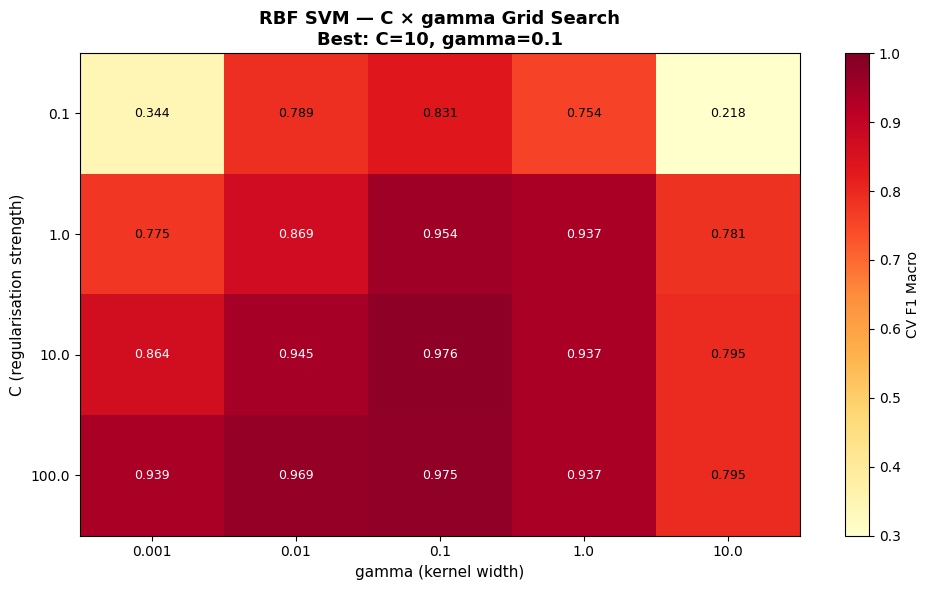

↑ gamma = kernel width: low → smooth, wide-influence boundaries; high → tight, local clusters.
  C = margin softness: low → wider margin tolerates misclassifications; high → harder margin.
  High gamma + high C is the classic overfitting corner — watch for inflated CV scores there.


In [4]:
results_df = pd.DataFrame(grid_rbf.cv_results_)
pivot = results_df.pivot_table(
    index="param_C", columns="param_gamma", values="mean_test_score",
).sort_index(axis=0).sort_index(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd", vmin=0.3, vmax=1.0)
ax.set_xticks(range(pivot.shape[1]))
ax.set_xticklabels([str(g) for g in pivot.columns], fontsize=10)
ax.set_yticks(range(pivot.shape[0]))
ax.set_yticklabels([str(c) for c in pivot.index], fontsize=10)
ax.set_xlabel("gamma (kernel width)", fontsize=11)
ax.set_ylabel("C (regularisation strength)", fontsize=11)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    fontsize=9, color="black" if val < 0.85 else "white")

plt.colorbar(im, ax=ax, label="CV F1 Macro")
ax.set_title(
    f"RBF SVM — C × gamma Grid Search\n"
    f"Best: C={grid_rbf.best_params_['C']}, gamma={grid_rbf.best_params_['gamma']}",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
save_plot("rbf_grid_heatmap")
plt.show()

print("↑ gamma = kernel width: low → smooth, wide-influence boundaries; high → tight, local clusters.")
print("  C = margin softness: low → wider margin tolerates misclassifications; high → harder margin.")
print("  High gamma + high C is the classic overfitting corner — watch for inflated CV scores there.")

### DIAGNOSTIC PLOT 2: Decision Function Score Distributions by True Class

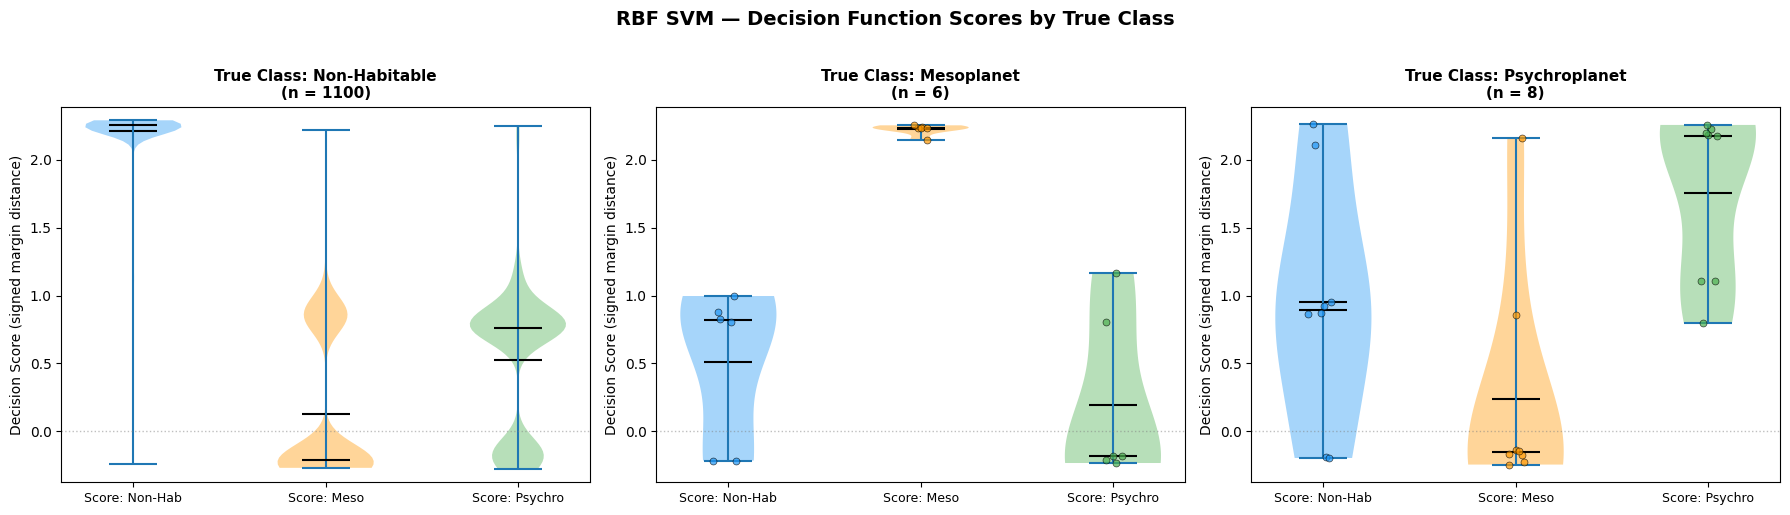

↑ Same interpretation as linear SVM, but the scores reflect distance in kernel-induced space.
  Expect more compressed margins than linear SVM — RBF carves tighter regions around minority clusters.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
score_labels = ["Score: Non-Hab", "Score: Meso", "Score: Psychro"]
y_test_arr = y_test.values if hasattr(y_test, "values") else np.asarray(y_test)

for true_cls in range(3):
    ax = axes[true_cls]
    mask = y_test_arr == float(true_cls)
    scores = y_dec_rbf[mask]

    if scores.shape[0] == 0:
        ax.set_title(f"True: {class_names[true_cls]}\n(no samples)")
        continue

    parts = ax.violinplot(
        [scores[:, c] for c in range(3)],
        positions=[0, 1, 2],
        showmeans=True,
        showmedians=True,
    )
    for pc, color in zip(parts["bodies"], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.4)
    for key in ("cmeans", "cmedians"):
        if key in parts:
            parts[key].set_color("black")

    if scores.shape[0] <= 50:
        rng = np.random.default_rng(42)
        for c in range(3):
            jitter = rng.normal(0, 0.04, size=scores.shape[0])
            ax.scatter(
                np.full(scores.shape[0], c) + jitter,
                scores[:, c],
                color=colors[c], s=25, alpha=0.7,
                edgecolors="black", linewidth=0.5, zorder=5,
            )

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(score_labels, fontsize=9)
    ax.set_ylabel("Decision Score (signed margin distance)")
    ax.set_ylim(y_dec_rbf.min() - 0.1, y_dec_rbf.max() + 0.1)
    ax.axhline(0, color="gray", ls=":", lw=1, alpha=0.5)
    ax.set_title(f"True Class: {class_names[true_cls]}\n(n = {mask.sum()})",
                 fontsize=11, fontweight="bold")

fig.suptitle("RBF SVM — Decision Function Scores by True Class",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_plot("rbf_decision_scores")
plt.show()

print("↑ Same interpretation as linear SVM, but the scores reflect distance in kernel-induced space.")
print("  Expect more compressed margins than linear SVM — RBF carves tighter regions around minority clusters.")

### DIAGNOSTIC PLOT 3: Support Vectors in PCA Space

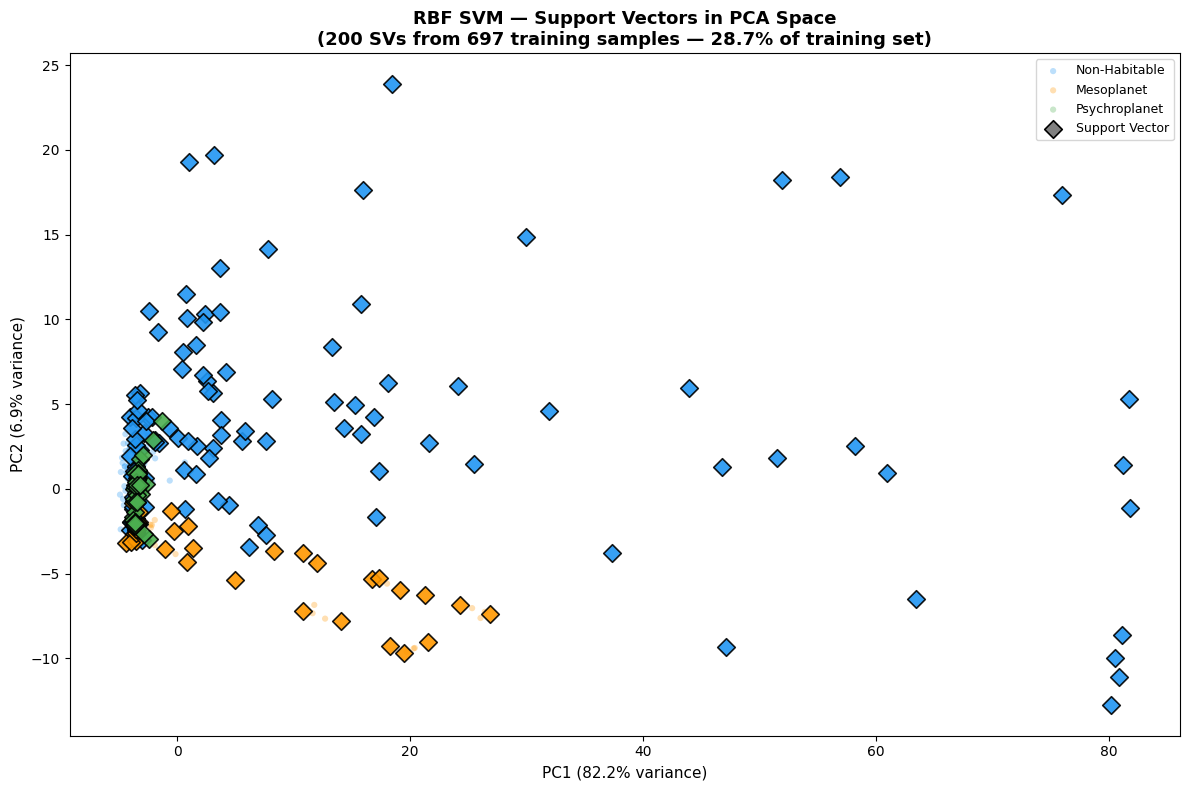

Support vectors per class: {'Non-Habitable': np.int32(118), 'Mesoplanet': np.int32(41), 'Psychroplanet': np.int32(41)}
↑ RBF typically uses a much higher fraction of training samples as SVs than linear SVM.
  Many minority-class points becoming SVs is expected — the kernel needs them to carve local regions.


In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_bal)

sv_mask = np.zeros(X_train_bal.shape[0], dtype=bool)
sv_mask[svm_rbf.support_] = True

y_train_arr = y_train_bal.values if hasattr(y_train_bal, "values") else np.asarray(y_train_bal)

fig, ax = plt.subplots(figsize=(12, 8))

for i, (cls, label, color) in enumerate(zip(classes, class_names, colors)):
    mask = y_train_arr == cls
    ax.scatter(X_train_pca[mask & ~sv_mask, 0], X_train_pca[mask & ~sv_mask, 1],
               c=color, label=label, alpha=0.3, s=20, edgecolors="none")
    ax.scatter(X_train_pca[mask & sv_mask, 0], X_train_pca[mask & sv_mask, 1],
               c=color, s=80, alpha=0.9, edgecolors="black", linewidth=1.2,
               marker="D", zorder=5)

ax.scatter([], [], c="gray", s=80, marker="D", edgecolors="black",
           linewidth=1.2, label="Support Vector")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=11)
ax.set_title(
    f"RBF SVM — Support Vectors in PCA Space\n"
    f"({svm_rbf.n_support_.sum()} SVs from {X_train_bal.shape[0]} training samples — "
    f"{svm_rbf.n_support_.sum() / X_train_bal.shape[0]:.1%} of training set)",
    fontsize=13, fontweight="bold",
)
ax.legend(fontsize=9)
plt.tight_layout()
save_plot("rbf_support_vectors_pca")
plt.show()

print(f"Support vectors per class: {dict(zip(class_names, svm_rbf.n_support_))}")
print("↑ RBF typically uses a much higher fraction of training samples as SVs than linear SVM.")
print("  Many minority-class points becoming SVs is expected — the kernel needs them to carve local regions.")

## Metrics
### Classification Report + F1 Scores

RBF SVM — Classification Report
               precision    recall  f1-score   support

Non-Habitable     0.9981    0.9745    0.9862      1100
   Mesoplanet     0.4615    1.0000    0.6316         6
Psychroplanet     0.1852    0.6250    0.2857         8

     accuracy                         0.9722      1114
    macro avg     0.5483    0.8665    0.6345      1114
 weighted avg     0.9894    0.9722    0.9793      1114

F1 Macro:    0.6345
F1 Weighted: 0.9793

5-Fold CV F1 Macro: 0.9789 ± 0.0098
F1 Macro:    0.6345
F1 Weighted: 0.9793


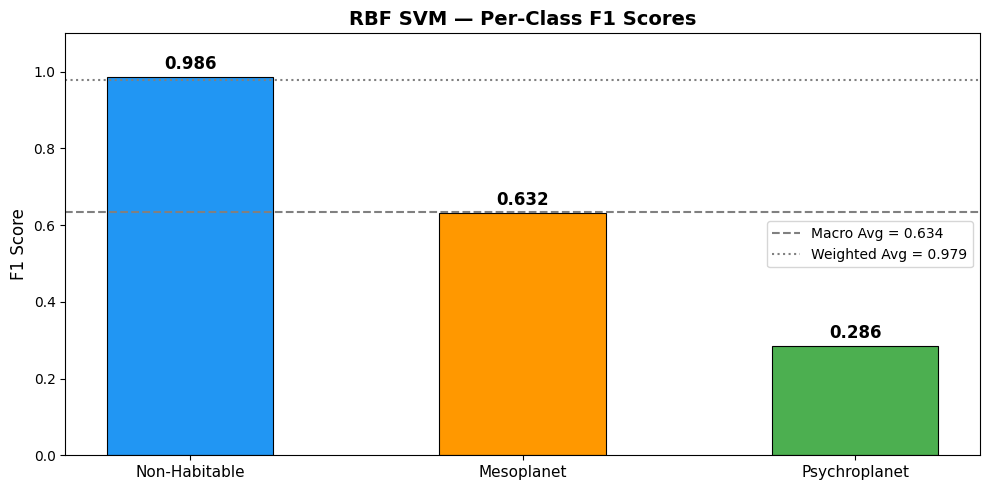

In [7]:
print_classification_report(y_test, y_pred_rbf, "RBF SVM")

f1_macro_rbf, f1_weighted_rbf, _ = compute_f1_scores(y_test, y_pred_rbf)

cv_scores_rbf = run_stratified_cv(svm_rbf, X_train_bal, y_train_bal)

plot_f1_bar(y_test, y_pred_rbf, "RBF SVM")

### Confusion Matrix (Counts + Normalized)

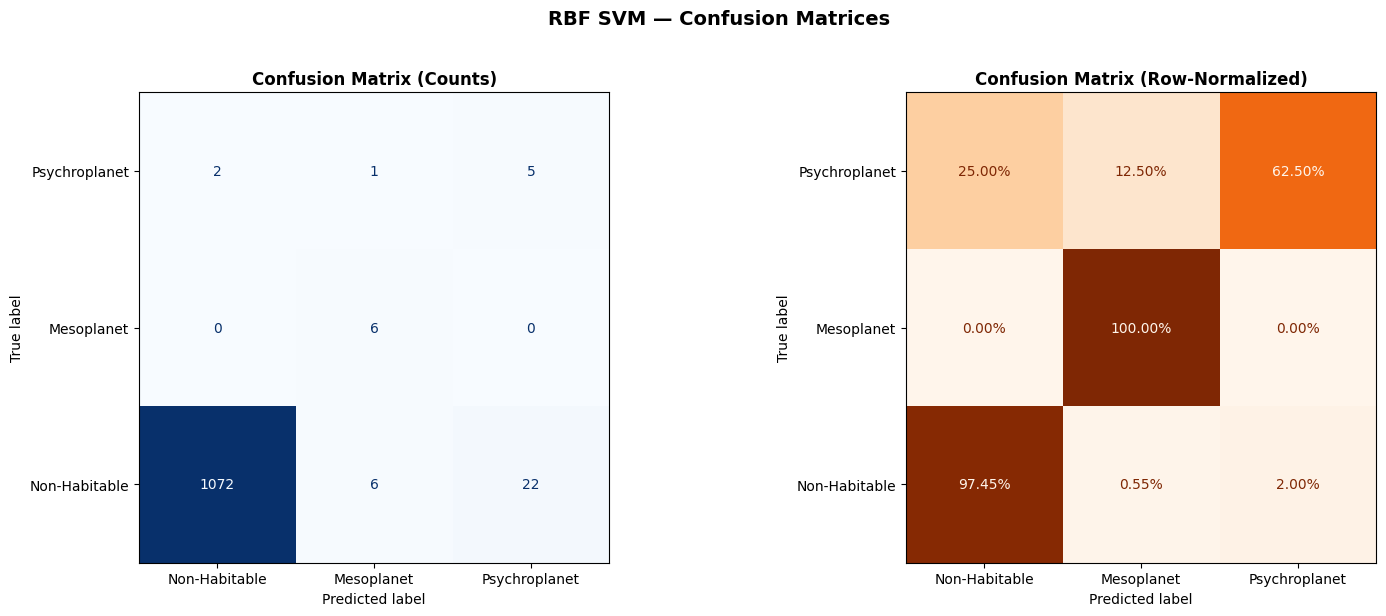

Key error patterns:
  Non-Habitable → predicted Mesoplanet: 6 (0.5% of true Non-Habitable)
  Non-Habitable → predicted Psychroplanet: 22 (2.0% of true Non-Habitable)
  Psychroplanet → predicted Non-Habitable: 2 (25.0% of true Psychroplanet)
  Psychroplanet → predicted Mesoplanet: 1 (12.5% of true Psychroplanet)


In [8]:
plot_confusion_matrices(y_test, y_pred_rbf, "RBF SVM")
print_error_patterns(y_test, y_pred_rbf)

## Interpretation:
